In [2]:
from statsmodels.graphics.gofplots import qqplot

from src.Preprocessing import get_preprocessed_data

X_train, X_test, y_train, y_test = get_preprocessed_data(output_as='random_split')

In [3]:
X_train.head()

,Latitude,Longitude,PostalCode,AttachedGarageYN,BathroomsTotalInteger,BedroomsTotal,FireplaceYN,GarageSpaces,LivingArea,MainLevelBedrooms,...,Flooring_Vinyl,Flooring_Laminate,Flooring_SeeRemarks,Flooring_Wood,Flooring_Brick,Flooring_Bamboo,Levels_ThreeOrMore,Levels_Two,Levels_One,Levels_MultiSplit
38274,-0.321713,0.118533,0.230263,0,0.0,1.0,0,0.0,-0.016268,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
13971,-0.420112,0.191335,0.140550,0,1.0,1.0,0,0.0,0.348325,-2.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
5891,-0.439796,0.063116,0.160287,0,2.0,0.0,0,0.0,1.378947,-3.0,...,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
36023,-0.387666,0.908424,-0.084928,0,0.0,0.0,0,0.0,-0.430622,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
75410,-0.905605,0.477600,-0.218900,0,1.0,0.0,0,0.0,0.056459,-3.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,-1.0,0.0


In [4]:
cols_with_na = []
for col in X_train.columns:
    na_count = X_train[col].isna().sum()
    print(f'{col}: {na_count} NAs')
    if na_count < 100:
        cols_with_na.append(col)



Latitude: 0 NAs
Longitude: 0 NAs
PostalCode: 0 NAs
AttachedGarageYN: 0 NAs
BathroomsTotalInteger: 0 NAs
BedroomsTotal: 0 NAs
FireplaceYN: 0 NAs
GarageSpaces: 0 NAs
LivingArea: 0 NAs
MainLevelBedrooms: 0 NAs
NewConstructionYN: 0 NAs
ParkingTotal: 0 NAs
PoolPrivateYN: 0 NAs
Stories: 0 NAs
ViewYN: 0 NAs
YearBuilt: 0 NAs
LotSizeAcres: 0 NAs
LotSizeArea: 0 NAs
LotSizeSquareFeet: 0 NAs
AssociationFee: 0 NAs
DaysOnMarket: 0 NAs
sin_closed_date: 0 NAs
Flooring_Concrete: 0 NAs
Flooring_Tile: 0 NAs
Flooring_Stone: 0 NAs
Flooring_Carpet: 0 NAs
Flooring_Vinyl: 0 NAs
Flooring_Laminate: 0 NAs
Flooring_SeeRemarks: 0 NAs
Flooring_Wood: 0 NAs
Flooring_Brick: 0 NAs
Flooring_Bamboo: 0 NAs
Levels_ThreeOrMore: 0 NAs
Levels_Two: 0 NAs
Levels_One: 0 NAs
Levels_MultiSplit: 0 NAs


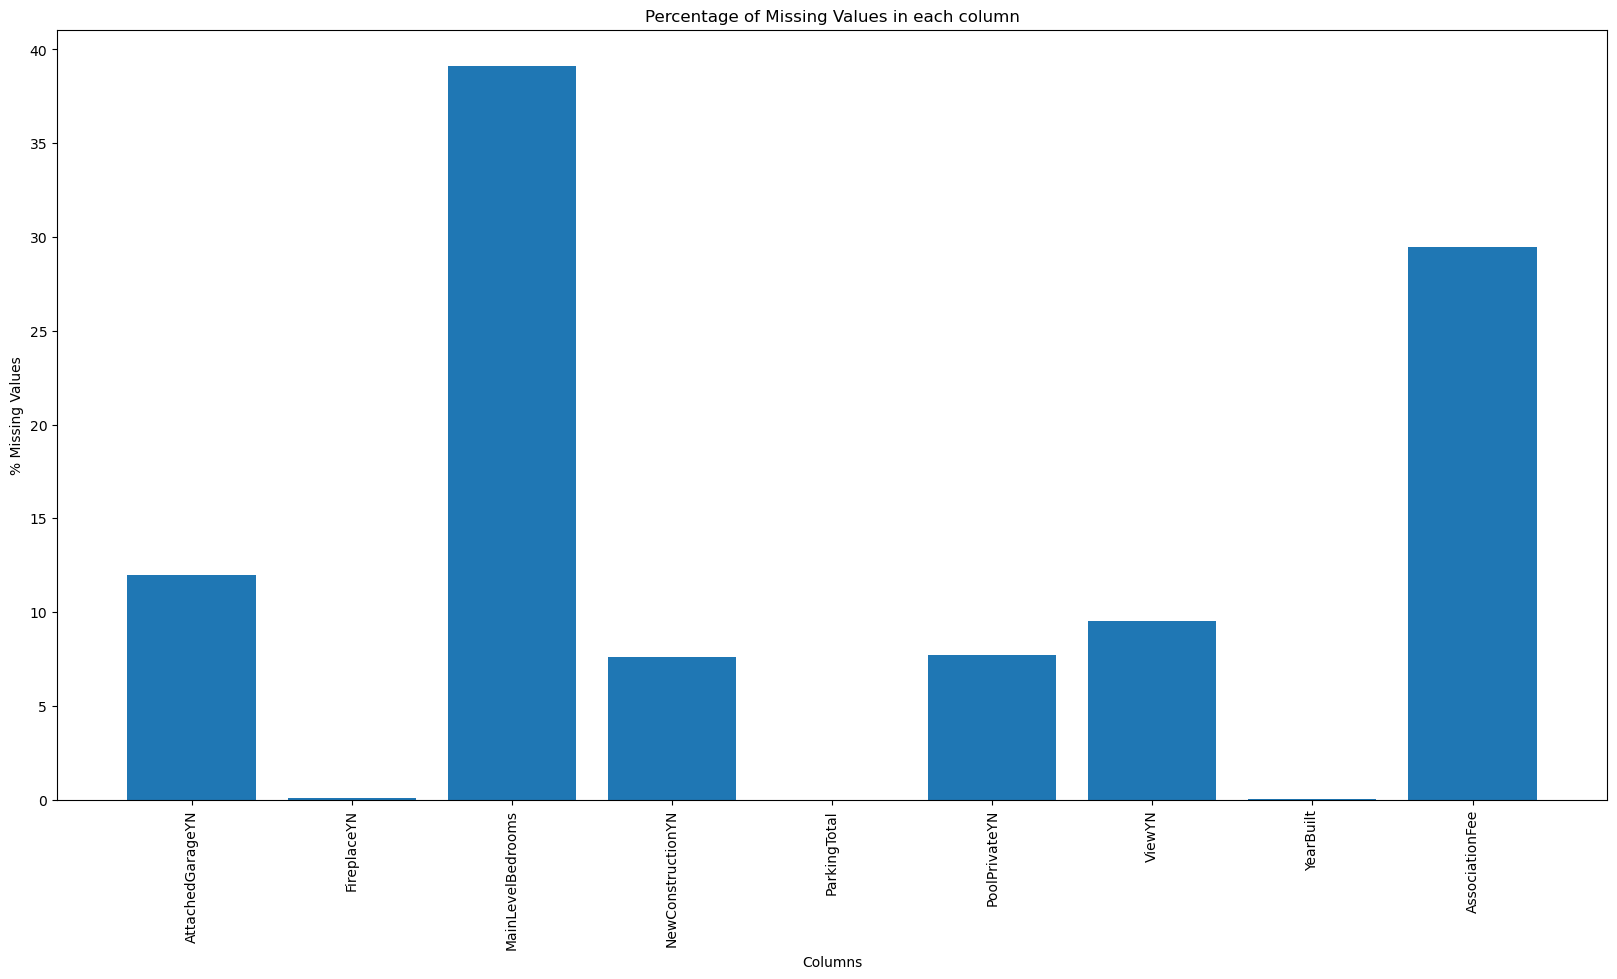

In [5]:
import pandas as pd
import matplotlib.pyplot as plt

def column_na_plot(df: pd.DataFrame):
    is_na = []
    data = df.copy()
    for column in data.columns:
        is_na_perc = data[column].isna().sum() * 100 / len(data[column])
        if is_na_perc > 0:
            is_na.append( is_na_perc )
        else:
            data.drop(column, axis=1, inplace=True)
    plt.figure(figsize = (20,10))
    plt.bar(x=data.columns, height=is_na)
    plt.xticks(rotation=90)
    plt.xlabel('Columns')
    plt.ylabel('% Missing Values')
    plt.title('Percentage of Missing Values in each column')
    plt.show()

column_na_plot(X_train)

### Assume values for missing value of YN columns are N

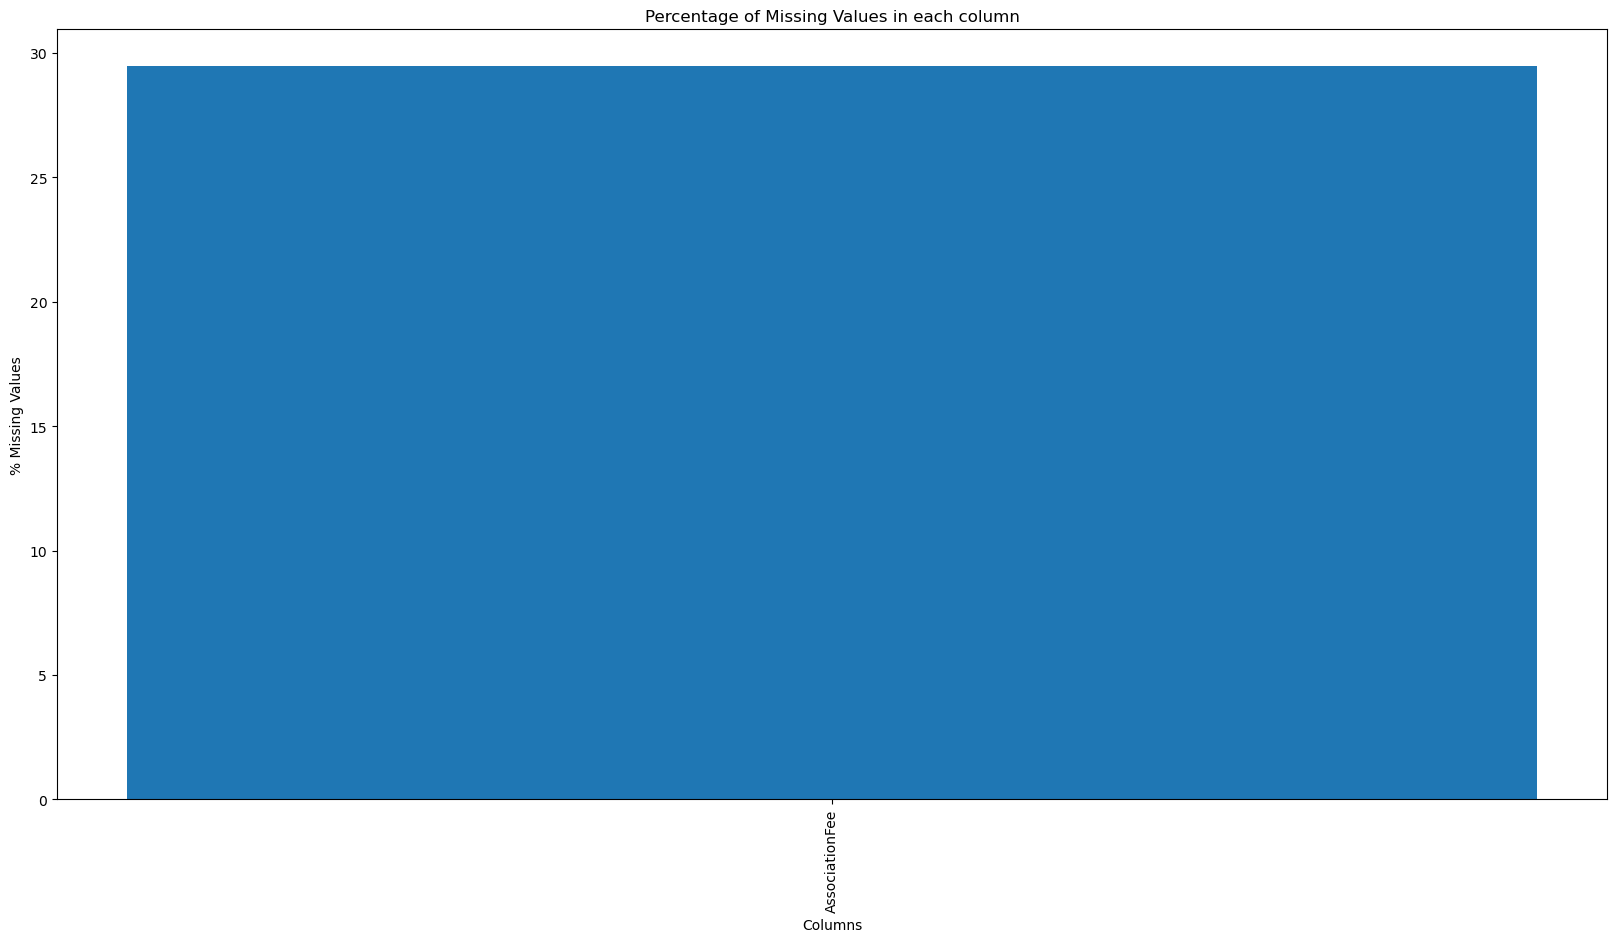

In [6]:
from sklearn.impute import SimpleImputer

imputer = SimpleImputer(strategy="most_frequent")
cols_to_impute = ['AttachedGarageYN', 'FireplaceYN', 'NewConstructionYN', 'PoolPrivateYN', 'ViewYN', 'ParkingTotal', 'YearBuilt', 'MainLevelBedrooms']

X_train[cols_to_impute] = imputer.fit_transform(X_train[cols_to_impute])
X_test[cols_to_impute] = imputer.fit_transform(X_test[cols_to_impute])

column_na_plot(X_train)

## Assume houses with missing HOA are houses with no HOA

In [7]:
def fill_zeros(x):
    if pd.isna(x):
        return 0
    else:
        return x

X_train['AssociationFee'] = X_train['AssociationFee'].apply(fill_zeros)
X_test['AssociationFee'] = X_test['AssociationFee'].apply(fill_zeros)

In [8]:
cols_with_na = []
for col in X_train.columns:
    na_count = X_train[col].isna().sum()
    print(f'{col}: {na_count} NAs')
    if na_count < 100:
        cols_with_na.append(col)

Latitude: 0 NAs
Longitude: 0 NAs
PostalCode: 0 NAs
AttachedGarageYN: 0 NAs
BathroomsTotalInteger: 0 NAs
BedroomsTotal: 0 NAs
FireplaceYN: 0 NAs
GarageSpaces: 0 NAs
LivingArea: 0 NAs
MainLevelBedrooms: 0 NAs
NewConstructionYN: 0 NAs
ParkingTotal: 0 NAs
PoolPrivateYN: 0 NAs
Stories: 0 NAs
ViewYN: 0 NAs
YearBuilt: 0 NAs
LotSizeAcres: 0 NAs
LotSizeArea: 0 NAs
LotSizeSquareFeet: 0 NAs
AssociationFee: 0 NAs
DaysOnMarket: 0 NAs
sin_closed_date: 0 NAs
Flooring_SeeRemarks: 0 NAs
Flooring_Tile: 0 NAs
Flooring_Stone: 0 NAs
Flooring_Vinyl: 0 NAs
Flooring_Bamboo: 0 NAs
Flooring_Brick: 0 NAs
Flooring_Carpet: 0 NAs
Flooring_Wood: 0 NAs
Flooring_Laminate: 0 NAs
Flooring_Concrete: 0 NAs
Levels_Two: 0 NAs
Levels_One: 0 NAs
Levels_MultiSplit: 0 NAs
Levels_ThreeOrMore: 0 NAs


# Eval with Random Forest

In [9]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split

rf = RandomForestRegressor(n_estimators=100, max_depth=20)

result = rf.fit(X=X_train, y=y_train)
result

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",20
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples 

In [14]:
y_pred = rf.predict(X_test)

from sklearn.metrics import r2_score, make_scorer
from sklearn.model_selection import cross_validate
import numpy as np

def mdape(y_pred, y_test):
    error = abs(y_test - y_pred)
    return np.median((error * 100) / y_test)

mdape_score = make_scorer(mdape, greater_is_better=False)

r2_result = cross_validate(rf, X=X_test, y=y_test, scoring=['r2', 'neg_median_absolute_error'], cv=5)
mdape_result = mdape(y_pred, y_test)

# print(f'MdAPE: {mdape_result}%')
print(f'R2: {r2_result}')

MdAPE: 0.5913310389333973%
R2: {'fit_time': array([4.37640905, 4.37325597, 4.32907009, 4.38217902, 4.25227904]), 'score_time': array([0.03671193, 0.03175712, 0.03176308, 0.03226209, 0.03058887]), 'test_r2': array([0.80698431, 0.84153681, 0.84973397, 0.85171412, 0.79432904]), 'test_neg_median_absolute_error': array([-0.10988931, -0.09386972, -0.09600795, -0.09670434, -0.11147099])}


In [15]:
def real_world_mdape(y_pred_log, y_test_log):
    # Convert back to original scale (e.g., Dollars)
    y_pred_actual = np.exp(y_pred_log)
    y_test_actual = np.exp(y_test_log)

    # Calculate percentage error on the actual values
    error = np.abs(y_test_actual - y_pred_actual)
    return np.median(error / y_test_actual) * 100

# Run this on your results
actual_mdape = real_world_mdape(y_pred, y_test)
print(f'Actual Price MdAPE: {actual_mdape:.2f}%')

Actual Price MdAPE: 8.09%


# The results are not good lol

Text(0.5, 0, 'residual')

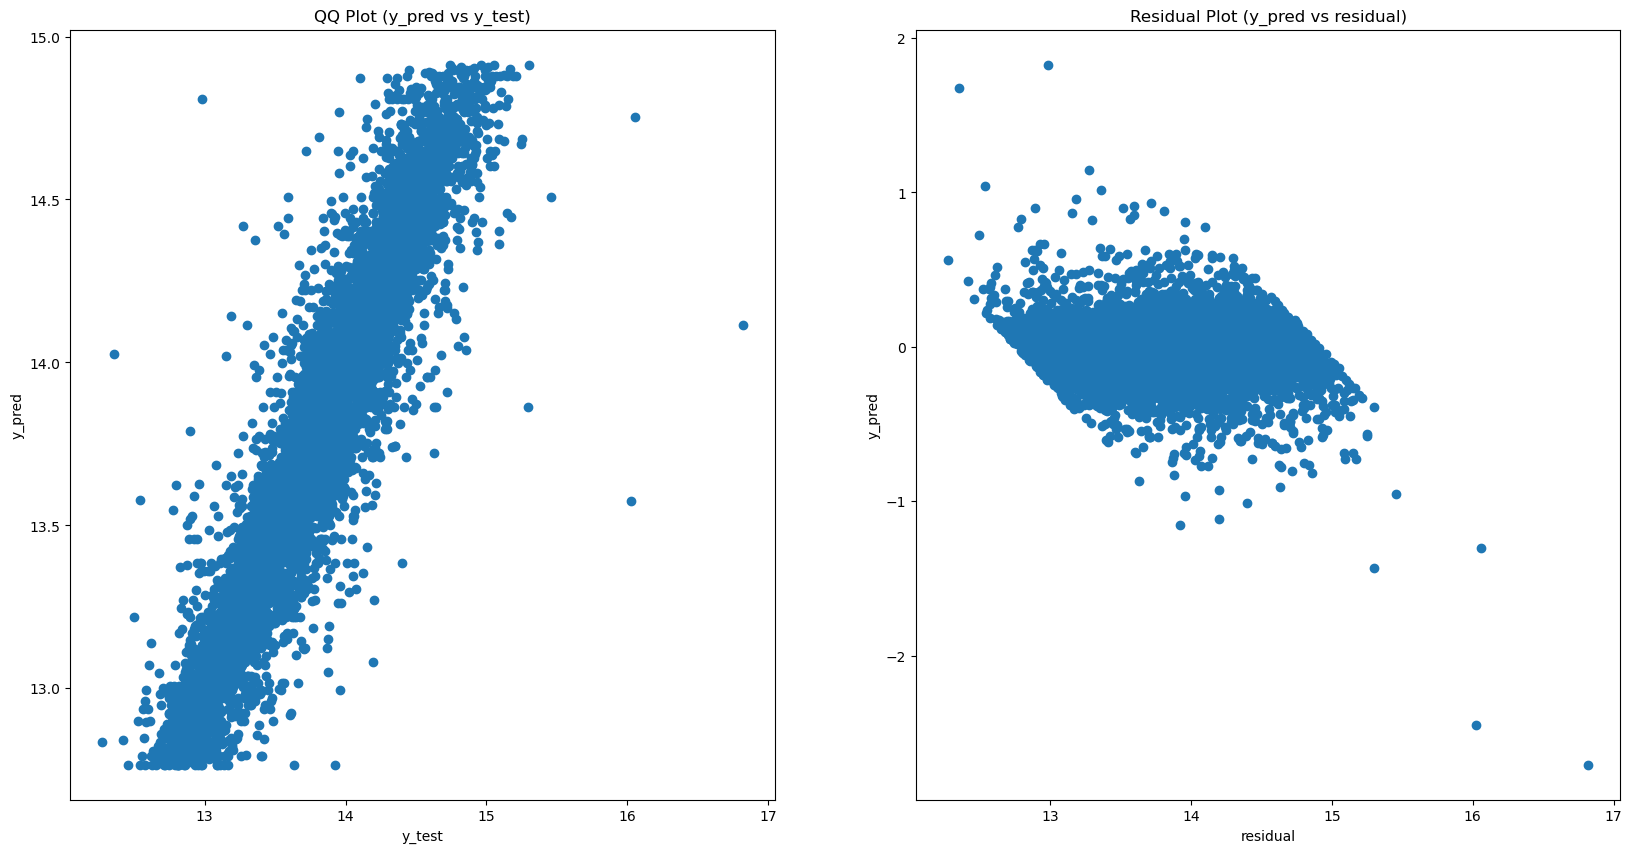

In [11]:
fig, axs = plt.subplots(nrows=1, ncols=2, figsize=(20,10))

axs[0].scatter(x=y_pred, y=y_test)
axs[0].set_title("QQ Plot (y_pred vs y_test)")
axs[0].set_ylabel("y_pred")
axs[0].set_xlabel("y_test")


axs[1].scatter(x=y_pred, y=y_test-y_pred)
axs[1].set_title("Residual Plot (y_pred vs residual)")
axs[1].set_ylabel("y")
axs[1].set_xlabel("residual")

In [12]:
import shap

explainer = shap.TreeExplainer(rf)
shap_val = explainer.shap_values(X_test[:1000])
shap.summary_plot

<function shap.plots._beeswarm.summary_legacy(shap_values, features=None, feature_names=None, max_display=None, plot_type=None, color=None, axis_color='#333333', title=None, alpha=1, show=True, sort=True, color_bar=True, plot_size='auto', layered_violin_max_num_bins=20, class_names=None, class_inds=None, color_bar_label='Feature value', cmap=<matplotlib.colors.LinearSegmentedColormap object at 0x16844fb90>, show_values_in_legend: 'bool' = False, use_log_scale: 'bool' = False, rng: 'np.random.Generator | None' = None)>

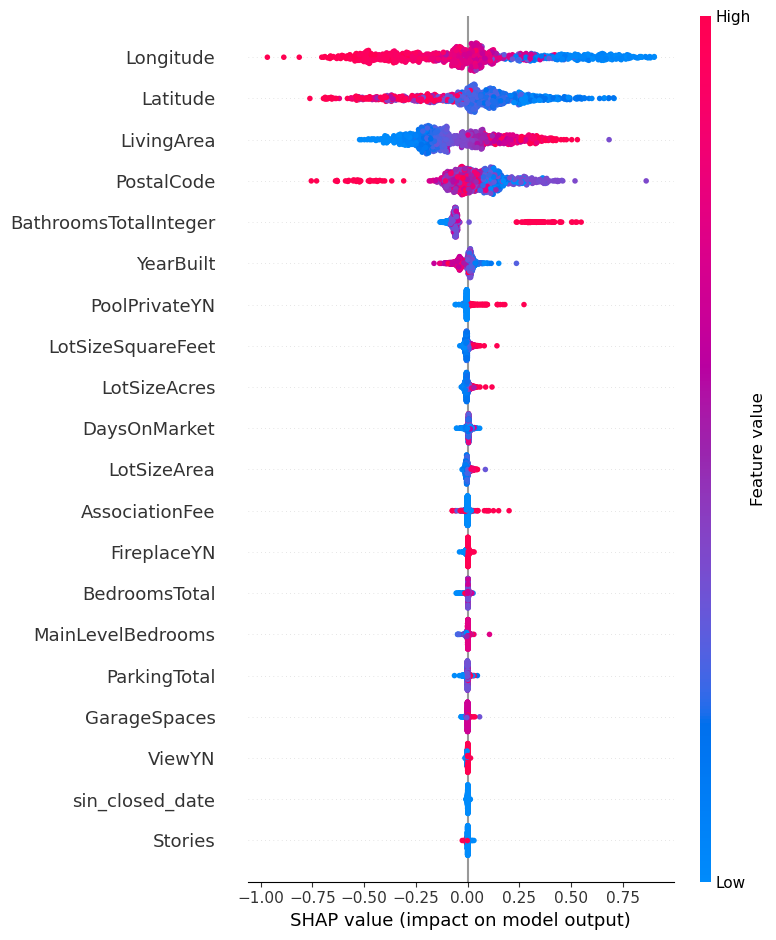

In [13]:
shap.summary_plot(shap_val, X_test[:1000])

### Geo info seems to have the most impact on log_price

In [18]:
from src.Preprocessing import get_preprocessed_data

X_train, X_test, y_train, y_test = get_preprocessed_data(output_as='random_split')

In [19]:
X_train

,Latitude,Longitude,PostalCode,AttachedGarageYN,BathroomsTotalInteger,BedroomsTotal,FireplaceYN,GarageSpaces,LivingArea,MainLevelBedrooms,...,Flooring_Wood,Flooring_SeeRemarks,Flooring_Vinyl,Flooring_Concrete,Flooring_Tile,Flooring_Bamboo,Levels_ThreeOrMore,Levels_One,Levels_Two,Levels_MultiSplit
38274,33.739072,-117.813055,92780.0,1.0,2.0,4.0,1.0,2.0,1797.0,3.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
13971,33.632275,-117.674872,92630.0,1.0,3.0,4.0,1.0,2.0,2178.0,1.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
5891,33.610911,-117.918239,92663.0,1.0,4.0,3.0,1.0,2.0,3255.0,0.0,...,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0
36023,33.667490,-116.313800,92253.0,1.0,2.0,3.0,1.0,2.0,1364.0,3.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
75410,33.105349,-117.131527,92029.0,1.0,3.0,3.0,0.0,2.0,1873.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6266,34.043309,-117.917170,91792.0,0.0,3.0,4.0,1.0,2.0,1736.0,4.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
54894,36.835091,-121.375439,95023.0,1.0,2.0,3.0,1.0,2.0,1680.0,3.0,...,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
76831,33.970609,-118.311686,90047.0,0.0,2.0,3.0,1.0,2.0,1761.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
860,32.617321,-117.047995,91911.0,1.0,2.0,3.0,0.0,2.0,1245.0,3.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0


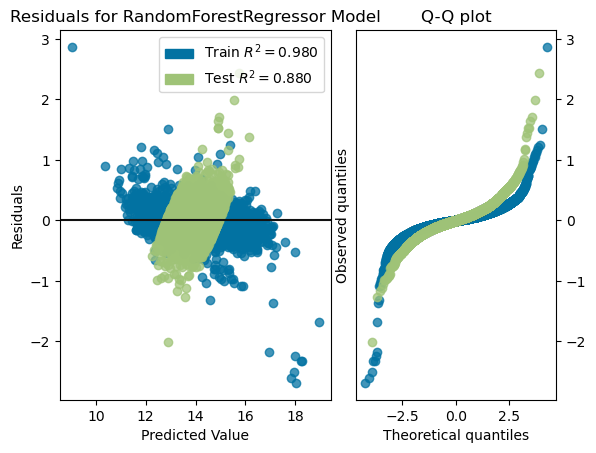

<Axes: title={'center': 'Residuals for RandomForestRegressor Model'}, xlabel='Predicted Value', ylabel='Residuals'>

In [21]:
from yellowbrick.regressor import ResidualsPlot
from sklearn.ensemble import RandomForestRegressor

X_train, X_test, y_train, y_test = get_preprocessed_data(output_as='random_split')
rf = RandomForestRegressor(n_estimators=100, max_depth=20)

visualizer = ResidualsPlot(rf, qqplot=True, hist=False)
visualizer.fit(X_train, y_train)
visualizer.score(X_test, y_test)
visualizer.show()


/Users/eddie/miniconda3/envs/houseML/lib/python3.13/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(


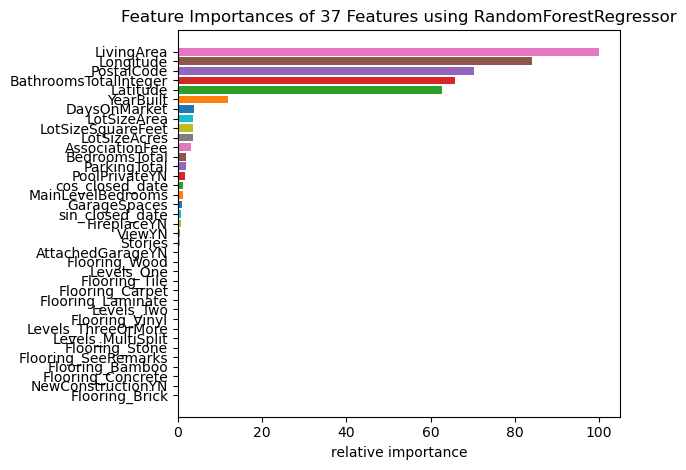

<Axes: title={'center': 'Feature Importances of 37 Features using RandomForestRegressor'}, xlabel='relative importance'>

In [23]:
from yellowbrick.model_selection import FeatureImportances
visualizer = FeatureImportances(rf)
visualizer.fit(X_train, y_train)
visualizer.show()
